# Temporal Stability of XAI Methods in Fraud Detection

This notebook implements the complete framework for analyzing temporal stability of SHAP and LIME explanations using rolling training windows on credit card fraud data.

## Framework Overview:
1. **Rolling Windows**: Train models on consecutive time windows
2. **Replica Training**: Bootstrap replicas with different random seeds to quantify model retraining instability
3. **Common Evaluation Slice**: Same future data for fair comparison
4. **Explanation Drift**: Cosine distance and RBO
5. **Contextualization**: Data drift, performance changes, drift ratios

In [83]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import wasserstein_distance
from itertools import combinations
import rbo
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configuration
DATA_PATH = "/content/drive/MyDrive/Thesis/CreditCard_Dataset/creditcard.csv"
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Prepare Data

In [85]:
df = pd.read_csv(DATA_PATH)

# Explicitly sort by time
df = df.sort_values('Time').reset_index(drop=True)

print(f"Dataset loaded successfully. Shape: {df.shape}")
print(f"Time range: {df['Time'].min():.0f} to {df['Time'].max():.0f} seconds")
print(f"Time span: {df['Time'].max() / 3600:.1f} hours")
print(f"Fraud rate: {df['Class'].mean():.4f}")
print(f"Data sorted by Time: ✓")

# Separate features for preprocessing
feature_cols = [col for col in df.columns if col not in ['Time', 'Class']]
print(f"\nFeatures to be standardized: {len(feature_cols)}")
print(f"Feature names: {feature_cols[:10]}...")

df.head()

Dataset loaded successfully. Shape: (284807, 31)
Time range: 0 to 172792 seconds
Time span: 48.0 hours
Fraud rate: 0.0017
Data sorted by Time: ✓

Features to be standardized: 29
Feature names: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']...


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [86]:
# Fit reference scaler on first training window (or entire dataset)
# This scaler will be used ONLY for drift calculations (XGBoost does not need scaling since it is tree based)
reference_window = df
reference_scaler = StandardScaler()
reference_scaler.fit(reference_window[feature_cols].values)
print(f"Reference scaler fitted on {len(reference_window)} transactions")

Reference scaler fitted on 284807 transactions


## 2. Temporal Window Configuration

We'll divide the data into discrete time steps and create rolling training windows. Based on the ~48 hour dataset, we'll use 6-hour time steps.

In [87]:
# Configuration for rolling windows
TIME_STEP_HOURS = 6  # Each time step is 6 hours
WINDOW_LENGTH = 3    # L = 3 time steps (18 hours of training data)
RETRAIN_STEP = 2     # s = 2, retrain every 2 time steps (12 hours)
EVAL_HORIZON = 2     # h = 2, evaluate on next 12 hours
NUM_REPLICAS = 5     # R = 5 replicas per model to quantify baseline instability

# Convert to seconds
TIME_STEP_SECONDS = TIME_STEP_HOURS * 3600

# Create time bins
max_time = df['Time'].max()
num_time_steps = int(np.ceil(max_time / TIME_STEP_SECONDS))

print(f"Configuration:")
print(f"  Time step: {TIME_STEP_HOURS} hours ({TIME_STEP_SECONDS} seconds)")
print(f"  Window length L: {WINDOW_LENGTH} time steps ({WINDOW_LENGTH * TIME_STEP_HOURS} hours)")
print(f"  Retrain step s: {RETRAIN_STEP} time step(s)")
print(f"  Evaluation horizon h: {EVAL_HORIZON} time step(s)")
print(f"  Number of replicas R: {NUM_REPLICAS}")
print(f"  Total time steps in dataset: {num_time_steps}")
print(f"  Maximum model pairs: {num_time_steps - WINDOW_LENGTH - RETRAIN_STEP - EVAL_HORIZON + 1}")

Configuration:
  Time step: 6 hours (21600 seconds)
  Window length L: 3 time steps (18 hours)
  Retrain step s: 2 time step(s)
  Evaluation horizon h: 2 time step(s)
  Number of replicas R: 5
  Total time steps in dataset: 8
  Maximum model pairs: 2


Transactions per time step:
           Total_Transactions  Fraud_Count  Fraud_Rate
time_step                                             
0                       12340           55      0.0045
1                       35061           91      0.0026
2                       46850           71      0.0015
3                       50535           64      0.0013
4                       11594           69      0.0060
5                       35851           27      0.0008
6                       49585           63      0.0013
7                       42991           52      0.0012


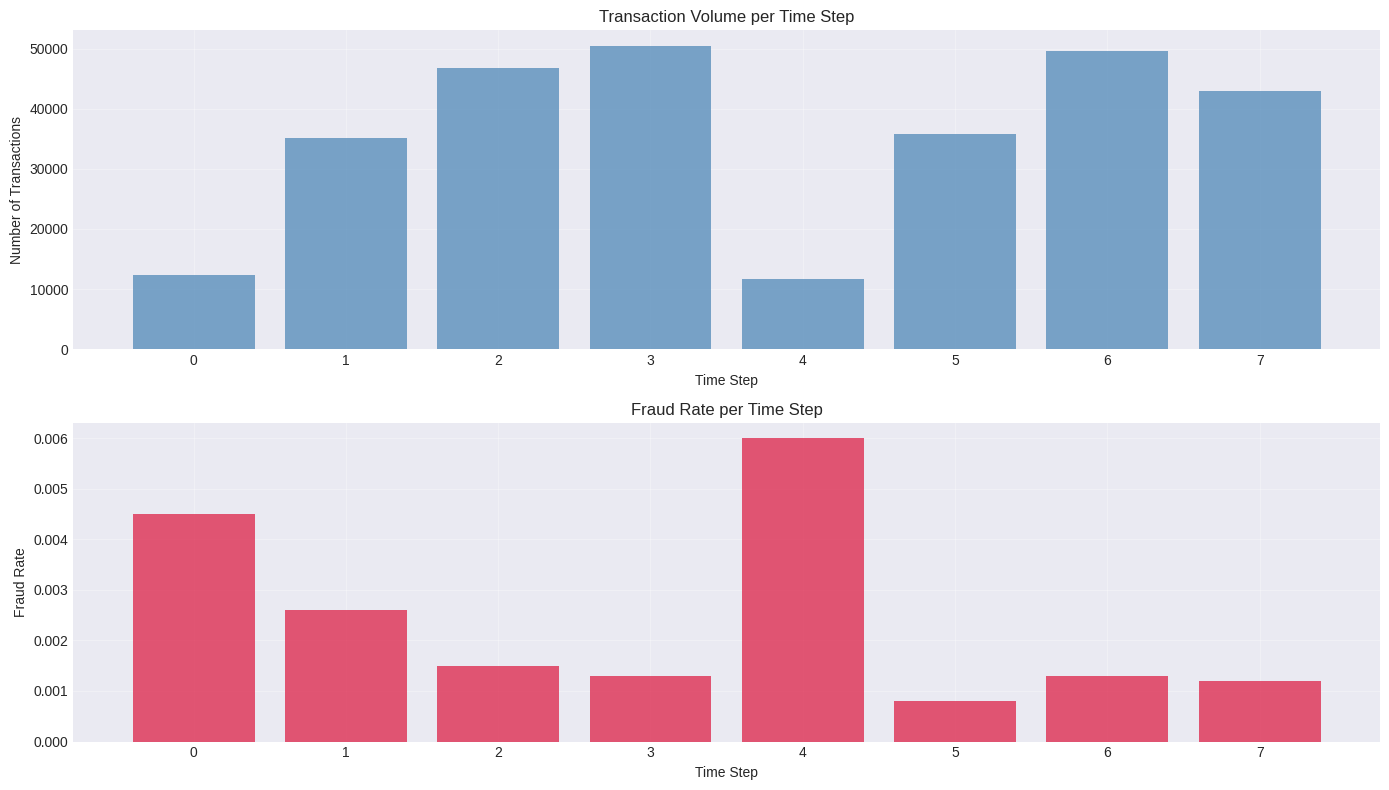

In [88]:
# Assign each transaction to a time step
df['time_step'] = (df['Time'] / TIME_STEP_SECONDS).astype(int)

# Display distribution of transactions across time steps
time_step_counts = df.groupby('time_step').agg({
    'Class': ['count', 'sum', 'mean']
}).round(4)
time_step_counts.columns = ['Total_Transactions', 'Fraud_Count', 'Fraud_Rate']
print("Transactions per time step:")
print(time_step_counts)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].bar(time_step_counts.index, time_step_counts['Total_Transactions'], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_title('Transaction Volume per Time Step')
axes[0].grid(True, alpha=0.3)

axes[1].bar(time_step_counts.index, time_step_counts['Fraud_Rate'], alpha=0.7, color='crimson')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_title('Fraud Rate per Time Step')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Helper functions

In [89]:
def get_window_data(df, end_step, window_length):
    """
    Get training window data ending at end_step with given window_length.
    W_k = union of time steps from (end_step - window_length + 1) to end_step
    """
    start_step = end_step - window_length + 1
    window_data = df[df['time_step'].between(start_step, end_step)].copy()
    return window_data

def get_eval_slice(df, start_step, horizon):
    """
    Get evaluation slice starting after start_step for horizon time steps.
    E_{A,B} = union of time steps from (start_step + 1) to (start_step + horizon)
    """
    eval_data = df[df['time_step'].between(start_step + 1, start_step + horizon)].copy()
    return eval_data

def compute_rbo(rank_a, rank_b, p=0.9):
    """
    Compute Rank-Biased Overlap (RBO) between two ranked lists using the rbo package.
    p is the persistence parameter (0.9 emphasizes top ranks).
    Returns similarity score between 0 and 1.
    """
    # Convert to lists if needed
    rank_a = list(rank_a)
    rank_b = list(rank_b)

    # Use the rbo package implementation
    rbo_similarity = rbo.RankingSimilarity(rank_a, rank_b).rbo(p=p)
    return rbo_similarity

def cosine_distance(vec_a, vec_b):
    """
    Compute cosine distance between two vectors using sklearn's cosine_similarity.
    Returns distance (1 - similarity) in range [0, 2].
    """
    if np.linalg.norm(vec_a) == 0 or np.linalg.norm(vec_b) == 0:
        return 1.0  # Maximum distance if either vector is zero

     # Reshape for sklearn (expects 2D arrays)
    vec_a_2d = vec_a.reshape(1, -1)
    vec_b_2d = vec_b.reshape(1, -1)

    # Compute cosine similarity and convert to distance
    similarity = cosine_similarity(vec_a_2d, vec_b_2d)[0, 0]
    return 1 - similarity


def rank_features_by_magnitude(attributions):
    """
    Rank features by absolute attribution magnitude (descending).
    Returns array of feature indices.
    """
    return np.argsort(-np.abs(attributions))


def get_best_replica(models, X_eval, y_eval):
    """
    Select the best-performing replica by PR-AUC on evaluation data.
    Returns the index of the best model.
    """
    best_idx = 0
    best_pr_auc = -1
    for i, model in enumerate(models):
        preds = model.predict_proba(X_eval)[:, 1]
        precision, recall, _ = precision_recall_curve(y_eval, preds)
        pr_auc = auc(recall, precision)
        if pr_auc > best_pr_auc:
            best_pr_auc = pr_auc
            best_idx = i
    return best_idx

print("Helper functions defined successfully!")

Helper functions defined successfully!


## 4. Model Training with Time-Series Cross-Validation and Hyperparameter Tuning

Each model is trained with:
1. **TimeSeriesSplit** cross-validation to prevent temporal leakage
2. **Hyperparameter tuning** using GridSearchCV
3. **Multiple bootstrap replicas** with different random seeds to quantify model retraining instability

In [90]:
def tune_hyperparameters(X_train, y_train, random_state=42):
    """
    Tune XGBoost hyperparameters using TimeSeriesSplit cross-validation.
    Returns best parameters.
    """
    # Calculate scale_pos_weight for imbalance
    fraud_rate = y_train.mean()
    scale_pos_weight = (1 - fraud_rate) / fraud_rate if fraud_rate > 0 else 1

    # Define parameter grid
    param_grid = {
        'n_estimators': [100],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.9],
        'colsample_bytree': [0.9]
    }

    # Base model
    base_model = xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
        tree_method='hist',
        device='cuda'
    )

    # TimeSeriesSplit for temporal cross-validation
    tscv = TimeSeriesSplit(n_splits=3)

    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=tscv,
        scoring='average_precision',  # PR-AUC
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)

    return grid_search.best_params_, grid_search.best_score_

def train_xgboost_replicas(train_data, num_replicas, feature_cols, target_col='Class'):
    """
    Train multiple XGBoost replicas with different random seeds.
    Uses hyperparameter tuning with TimeSeriesSplit for each replica.
    Each replica is trained on a bootstrap sample of the training data.
    Returns list of trained models, and best hyperparameters.
    """
    # Separate features and target
    X_train = train_data[feature_cols].values
    y_train = train_data[target_col].values

    # Calculate scale_pos_weight for imbalance
    fraud_rate = y_train.mean()
    scale_pos_weight = (1 - fraud_rate) / fraud_rate if fraud_rate > 0 else 1

    # Tune hyperparameters once on the full training data (using first replica's seed)
    print(f"  Tuning hyperparameters with TimeSeriesSplit CV...")
    best_params, best_score = tune_hyperparameters(X_train, y_train, random_state=42)
    print(f"  Best CV score (PR-AUC): {best_score:.4f}")
    print(f"  Best params: {best_params}")

    # Train replicas with tuned hyperparameters, different random seeds, and bootstrap samples
    models = []
    for r in range(num_replicas):
        seed = 42 + r  # Different seed for each replica

        # Draw bootstrap sample using replica seed
        rng = np.random.RandomState(seed)
        bootstrap_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
        X_boot = X_train[bootstrap_idx]
        y_boot = y_train[bootstrap_idx]

        model = xgb.XGBClassifier(
            **best_params,
            scale_pos_weight=scale_pos_weight,
            random_state=seed,
            eval_metric='logloss',
            use_label_encoder=False,
            n_jobs=-1,
            tree_method='hist',
            device='cuda'
        )

        model.fit(X_boot, y_boot, verbose=False)
        models.append(model)

    return models, best_params

def predict_replicas(models, X):
    """Get predictions from all replicas and return averaged predictions."""
    predictions = np.array([model.predict_proba(X)[:, 1] for model in models])
    return predictions.mean(axis=0)

def get_fraud_predictions(models, X, threshold=0.5):
    """
    Get fraud predictions from replicas.
    Returns boolean array indicating which instances are predicted as fraud.
    """
    avg_predictions = predict_replicas(models, X)
    return avg_predictions >= threshold

print("Model training functions with hyperparameter tuning defined!")

Model training functions with hyperparameter tuning defined!


## 5. Explanation Generation (SHAP and LIME) - Fraud-Flagged Transactions Only

**Important**: Fraud investigators only examine explanations for transactions flagged as fraud. We compute explanations only for instances predicted as fraud by either Model A or Model B.

In [91]:
def compute_shap_attributions(models, X, feature_cols):
    """
    Compute SHAP attributions for all replicas and return averaged attributions.
    Uses TreeExplainer for XGBoost models.
    """
    all_shap_values = []

    for model in models:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        all_shap_values.append(shap_values)

    # Average across replicas
    avg_shap_values = np.mean(all_shap_values, axis=0)
    return avg_shap_values, all_shap_values

def compute_lime_attributions(models, X_train, X_test, feature_cols, num_samples=1000):
    """
    Compute LIME attributions for all replicas and return averaged attributions.
    Note: LIME is computed per instance, so this returns a matrix.
    """
    # Create LIME explainer using training data
    explainer = LimeTabularExplainer(
        X_train,
        feature_names=feature_cols,
        class_names=['Legitimate', 'Fraud'],
        mode='classification',
        random_state=42
    )

    all_lime_values = []

    for model in models:
        lime_values = []

        # For each instance in test set
        for i in range(len(X_test)):
            # Get explanation
            exp = explainer.explain_instance(
                X_test[i],
                model.predict_proba,
                num_features=len(feature_cols),
                num_samples=num_samples
            )

            # Extract feature attributions using indices directly from local_exp
            # local_exp[1] contains explanations for class 1 (fraud)
            # It's a list of (feature_index, attribution_value) tuples
            attributions = np.zeros(len(feature_cols))

            for feature_idx, attribution_value in exp.local_exp[1]:
                attributions[feature_idx] = attribution_value

            lime_values.append(attributions)

        all_lime_values.append(np.array(lime_values))

    # Average across replicas
    avg_lime_values = np.mean(all_lime_values, axis=0)
    return avg_lime_values, all_lime_values

print("Explanation functions defined!")

Explanation functions defined!


## 6. Data Drift Metrics

In [92]:
def compute_covariate_drift(data_a, data_b, feature_cols, reference_scaler):
    """
    Compute covariate drift using average Wasserstein distance across features.
    """
    # Transform both windows with the SAME reference scaler
    X_a_scaled = reference_scaler.transform(data_a[feature_cols].values)
    X_b_scaled = reference_scaler.transform(data_b[feature_cols].values)

    wasserstein_distances = []
    for i in range(len(feature_cols)):
        wd = wasserstein_distance(X_a_scaled[:, i], X_b_scaled[:, i])
        wasserstein_distances.append(wd)

    # Return mean Wasserstein distance
    return np.mean(wasserstein_distances)

def compute_target_drift(data_a, data_b, target_col='Class'):
    """
    Compute target drift as absolute difference in fraud rates.
    """
    fraud_rate_a = data_a[target_col].mean()
    fraud_rate_b = data_b[target_col].mean()
    return abs(fraud_rate_a - fraud_rate_b)

def compute_performance_change(models_a, models_b, eval_data, feature_cols, target_col='Class'):
    """
    Compute performance change between model A and B on evaluation slice.
    Returns delta_perf = Loss(A) - Loss(B), where positive means B is better.
    Uses 1 - PR-AUC as loss.
    """
    X_eval = eval_data[feature_cols].values
    y_eval = eval_data[target_col].values


    # Get averaged predictions
    pred_a = predict_replicas(models_a, X_eval)
    pred_b = predict_replicas(models_b, X_eval)

    # Compute PR-AUC for both
    precision_a, recall_a, _ = precision_recall_curve(y_eval, pred_a)
    pr_auc_a = auc(recall_a, precision_a)

    precision_b, recall_b, _ = precision_recall_curve(y_eval, pred_b)
    pr_auc_b = auc(recall_b, precision_b)

    # Loss = 1 - PR-AUC (lower is better)
    loss_a = 1 - pr_auc_a
    loss_b = 1 - pr_auc_b

    delta_perf = loss_a - loss_b  # Positive if B is better

    return delta_perf, pr_auc_a, pr_auc_b

print("Data drift functions defined!")

Data drift functions defined!


## 7. Explanation Drift Metrics

In [93]:
def compute_baseline_instability(attr_all_replicas):
    """
    Compute baseline instability for a single instance across replicas.
    Returns median pairwise distance across all replica pairs.
    """
    num_replicas = len(attr_all_replicas)

    # Compute pairwise distances
    cos_distances = []
    rbo_distances = []

    for r1, r2 in combinations(range(num_replicas), 2):
        attr_r1 = attr_all_replicas[r1]
        attr_r2 = attr_all_replicas[r2]

        # Cosine distance
        cos_dist = cosine_distance(attr_r1, attr_r2)
        cos_distances.append(cos_dist)

        # RBO distance
        rank_r1 = rank_features_by_magnitude(attr_r1)
        rank_r2 = rank_features_by_magnitude(attr_r2)
        rbo_sim = compute_rbo(rank_r1, rank_r2, p=0.9)
        rbo_distances.append(1 - rbo_sim)

    return {
        'cosine_baseline': np.median(cos_distances),
        'rbo_baseline': np.median(rbo_distances)
    }


def compute_cross_window_instability(attr_a_replicas, attr_b_replicas):
    """
    Compute dynamic instability for a single instance by comparing all cross-window
    replica pairs (every replica from A vs every replica from B, R×R pairs).
    Returns mean pairwise distance across all R×R cross-window pairs.
    """
    cos_distances = []
    rbo_distances = []

    for attr_a in attr_a_replicas:
        for attr_b in attr_b_replicas:
            cos_dist = cosine_distance(attr_a, attr_b)
            cos_distances.append(cos_dist)

            rank_a = rank_features_by_magnitude(attr_a)
            rank_b = rank_features_by_magnitude(attr_b)
            rbo_sim = compute_rbo(rank_a, rank_b, p=0.9)
            rbo_distances.append(1 - rbo_sim)

    return {
        'cosine_dynamic': np.mean(cos_distances),
        'rbo_dynamic': np.mean(rbo_distances)
    }


def compute_global_drift_shap(shap_a_avg, shap_b_avg):
    """
    Compute global drift for SHAP by comparing feature importance rankings.

    Parameters:
    - shap_a_avg, shap_b_avg: Arrays of shape (n_instances, n_features)

    Returns global drift based on RBO of feature importance rankings.
    """
    # Compute global importance: mean absolute SHAP value per feature
    global_importance_a = np.mean(np.abs(shap_a_avg), axis=0)
    global_importance_b = np.mean(np.abs(shap_b_avg), axis=0)

    # Rank features by importance
    rank_a = np.argsort(-global_importance_a)
    rank_b = np.argsort(-global_importance_b)

    # Compute RBO
    rbo_sim = compute_rbo(rank_a, rank_b, p=0.9)
    global_drift = 1 - rbo_sim

    return global_drift, global_importance_a, global_importance_b


def compute_shap_explainer_instability(model, X, num_runs=5):
    """
    Compute SHAP explainer instability by running TreeExplainer num_runs times on the same model.
    Since TreeExplainer is deterministic, this is expected to show near-zero variability.
    Returns list of attribution arrays (one per run, shape: n_instances x n_features).
    """
    explainer = shap.TreeExplainer(model)
    all_shap_values = []
    for _ in range(num_runs):
        shap_values = explainer.shap_values(X)
        all_shap_values.append(shap_values)
    return all_shap_values


def compute_lime_explainer_instability(model, X_train, X_test, feature_cols, num_runs=5, num_samples=3000):
    """
    Compute LIME explainer instability by running with different random seeds on the same model.
    Returns list of attribution arrays (one per run, shape: n_instances x n_features).
    """
    all_lime_values = []
    for run in range(num_runs):
        explainer = LimeTabularExplainer(
            X_train,
            feature_names=feature_cols,
            class_names=['Legitimate', 'Fraud'],
            mode='classification',
            random_state=100 + run
        )
        lime_values = []
        for i in range(len(X_test)):
            exp = explainer.explain_instance(
                X_test[i],
                model.predict_proba,
                num_features=len(feature_cols),
                num_samples=num_samples
            )
            attributions = np.zeros(len(feature_cols))
            for feature_idx, attribution_value in exp.local_exp[1]:
                attributions[feature_idx] = attribution_value
            lime_values.append(attributions)
        all_lime_values.append(np.array(lime_values))
    return all_lime_values

print("Explanation drift functions defined!")

Explanation drift functions defined!


## 8. Main Experiment Loop

This is the core implementation that:
1. Iterates through all valid window pairs (A, B)
2. Trains replicas for each model version with **hyperparameter tuning** and **TimeSeriesSplit CV**
3. **Raw (unscaled) features** are passed to XGBoost (tree-based, no scaling needed). A reference StandardScaler fitted on the full dataset is used for data drift measurements only.
4. Identifies **fraud-flagged transactions** (predicted as fraud by either model A or B) and takes the union of both.
Goal is to measure difference, while still comparing the same transactions for model A and B --> **Evaluation on a common evaluation slice**
5. Computes explanations (SHAP and LIME) **only for flagged transactions**
6. Calculates all drift metrics, retraining instability, explainer instability, and drift ratios

In [94]:
def run_temporal_stability_experiment(df, feature_cols, window_length, retrain_step,
                                      eval_horizon, num_replicas, max_pairs=None,
                                      use_shap=True, use_lime=False, fraud_threshold=0.5):
    """
    Main experiment loop for temporal stability analysis.

    Parameters:
    - df: DataFrame with 'time_step' column
    - feature_cols: List of feature column names
    - window_length: L (number of time steps in training window)
    - retrain_step: s (retrain every s time steps)
    - eval_horizon: h (evaluation horizon in time steps)
    - num_replicas: R (number of replicas per model)
    - max_pairs: Maximum number of model pairs to evaluate (None = all)
    - use_shap: Whether to compute SHAP explanations
    - use_lime: Whether to compute LIME explanations (slower)
    - fraud_threshold: Threshold for flagging transactions as fraud

    Returns: DataFrame with all metrics for each model pair
    """
    results = []

    # Determine valid window pairs
    valid_pairs = []
    for k_a in range(window_length - 1, num_time_steps - retrain_step - eval_horizon):
        k_b = k_a + retrain_step
        valid_pairs.append((k_a, k_b))
    
    if max_pairs is not None:
        valid_pairs = valid_pairs[:max_pairs]


    print(f"Found {len(valid_pairs)} valid model pairs to evaluate")
    print(f"Window length: {window_length} steps, Retrain step: {retrain_step}, Eval horizon: {eval_horizon}")
    print(f"Number of replicas: {num_replicas}")
    print(f"Fraud threshold: {fraud_threshold}")
    print(f"Computing SHAP: {use_shap}, Computing LIME: {use_lime}\n")

    # Process each pair
    for pair_idx, (k_a, k_b) in enumerate(valid_pairs):
        print(f"\n{'='*80}")
        print(f"Processing pair {pair_idx + 1}/{len(valid_pairs)}: Window A ends at t={k_a}, Window B ends at t={k_b}")
        print(f"{'='*80}")

        # Get training windows
        window_a = get_window_data(df, k_a, window_length)
        window_b = get_window_data(df, k_b, window_length)

        # Get common evaluation slice
        eval_slice = get_eval_slice(df, k_b, eval_horizon)

        print(f"Window A: {len(window_a)} transactions (steps {k_a - window_length + 1} to {k_a})")
        print(f"  Fraud rate: {window_a['Class'].mean():.4f}")
        print(f"Window B: {len(window_b)} transactions (steps {k_b - window_length + 1} to {k_b})")
        print(f"  Fraud rate: {window_b['Class'].mean():.4f}")
        print(f"Eval slice: {len(eval_slice)} transactions (steps {k_b + 1} to {k_b + eval_horizon})")
        print(f"  Fraud rate: {eval_slice['Class'].mean():.4f}")

        if len(eval_slice) == 0:
            print("Warning: Empty evaluation slice, skipping this pair")
            continue

        # Train replicas for both models (includes hyperparameter tuning)
        print(f"\nTraining {num_replicas} replicas for Model A with hyperparameter tuning...")
        models_a, best_params_a = train_xgboost_replicas(window_a, num_replicas, feature_cols)

        print(f"\nTraining {num_replicas} replicas for Model B with hyperparameter tuning...")
        models_b, best_params_b = train_xgboost_replicas(window_b, num_replicas, feature_cols)

        # Prepare evaluation data (raw features)
        X_eval = eval_slice[feature_cols].values
        y_eval = eval_slice['Class'].values

        # Identify fraud-flagged transactions (predicted as fraud by either model)
        print("\nIdentifying fraud-flagged transactions...")
        flagged_a = get_fraud_predictions(models_a, X_eval, threshold=fraud_threshold)
        flagged_b = get_fraud_predictions(models_b, X_eval, threshold=fraud_threshold)
        flagged_union = flagged_a | flagged_b  # Union: flagged by either model

        num_flagged = flagged_union.sum()
        print(f"  Model A flagged: {flagged_a.sum()} transactions")
        print(f"  Model B flagged: {flagged_b.sum()} transactions")
        print(f"  Union (either model): {num_flagged} transactions ({num_flagged/len(eval_slice)*100:.2f}%)")

        if num_flagged == 0:
            print("Warning: No transactions flagged as fraud, skipping explanation analysis")
            # Still compute data drift and performance
            covariate_drift = compute_covariate_drift(window_a, window_b, feature_cols, reference_scaler)
            target_drift = compute_target_drift(window_a, window_b)
            delta_perf, pr_auc_a, pr_auc_b = compute_performance_change(
                models_a, models_b, eval_slice, feature_cols)

            result = {
                'pair_idx': pair_idx,
                'window_a_end': k_a,
                'window_b_end': k_b,
                'eval_size': len(eval_slice),
                'num_flagged': 0,
                'covariate_drift': covariate_drift,
                'target_drift': target_drift,
                'pr_auc_a': pr_auc_a,
                'pr_auc_b': pr_auc_b,
                'delta_perf': delta_perf
            }
            results.append(result)
            continue

        # Filter to flagged transactions only
        X_eval_flagged = X_eval[flagged_union]

        # Select best replica of model A (used for explainer instability baseline)
        best_idx_a = get_best_replica(models_a, X_eval, y_eval)

        # Compute data drift
        print("\nComputing data drift metrics...")
        covariate_drift = compute_covariate_drift(window_a, window_b, feature_cols, reference_scaler)
        target_drift = compute_target_drift(window_a, window_b)

        # Compute performance change
        print("Computing performance metrics...")
        delta_perf, pr_auc_a, pr_auc_b = compute_performance_change(
            models_a, models_b, eval_slice, feature_cols
        )

        result = {
            'pair_idx': pair_idx,
            'window_a_end': k_a,
            'window_b_end': k_b,
            'eval_size': len(eval_slice),
            'num_flagged': num_flagged,
            'pct_flagged': num_flagged / len(eval_slice) * 100,
            'covariate_drift': covariate_drift,
            'target_drift': target_drift,
            'pr_auc_a': pr_auc_a,
            'pr_auc_b': pr_auc_b,
            'delta_perf': delta_perf,
            'best_params_a': str(best_params_a),
            'best_params_b': str(best_params_b)
        }

        # SHAP analysis (only on flagged transactions)
        if use_shap:
            print(f"\nComputing SHAP explanations for {num_flagged} flagged transactions...")
            shap_a_avg, shap_a_all = compute_shap_attributions(models_a, X_eval_flagged, feature_cols)
            shap_b_avg, shap_b_all = compute_shap_attributions(models_b, X_eval_flagged, feature_cols)

            # Dynamic (cross-window) and static (within-window) instability per instance
            dynamic_cos_dists = []
            dynamic_rbo_dists = []
            static_cos_a = []
            static_rbo_a = []
            static_cos_b = []
            static_rbo_b = []

            print(f"Computing instability metrics for {num_flagged} flagged instances...")
            for i in range(num_flagged):
                # Dynamic instability: all cross-window replica pairs (Ai vs Bj)
                dynamic_metrics = compute_cross_window_instability(
                    [shap_a_all[r][i] for r in range(num_replicas)],
                    [shap_b_all[r][i] for r in range(num_replicas)]
                )
                dynamic_cos_dists.append(dynamic_metrics['cosine_dynamic'])
                dynamic_rbo_dists.append(dynamic_metrics['rbo_dynamic'])

                # Static instability within A (Ai vs Aj)
                static_a = compute_baseline_instability(
                    [shap_a_all[r][i] for r in range(num_replicas)]
                )
                static_cos_a.append(static_a['cosine_baseline'])
                static_rbo_a.append(static_a['rbo_baseline'])

                # Static instability within B (Bi vs Bj)
                static_b = compute_baseline_instability(
                    [shap_b_all[r][i] for r in range(num_replicas)]
                )
                static_cos_b.append(static_b['cosine_baseline'])
                static_rbo_b.append(static_b['rbo_baseline'])

            # Aggregate with median
            result['shap_dynamic_cos'] = np.median(dynamic_cos_dists)
            result['shap_dynamic_rbo'] = np.median(dynamic_rbo_dists)

            # Static instability: separate for A and B, plus aggregated mean
            result['shap_static_cos_a'] = np.median(static_cos_a)
            result['shap_static_rbo_a'] = np.median(static_rbo_a)
            result['shap_static_cos_b'] = np.median(static_cos_b)
            result['shap_static_rbo_b'] = np.median(static_rbo_b)
            result['shap_static_cos_mean'] = (result['shap_static_cos_a'] + result['shap_static_cos_b']) / 2
            result['shap_static_rbo_mean'] = (result['shap_static_rbo_a'] + result['shap_static_rbo_b']) / 2

            # Drift ratios (dynamic / static mean)
            epsilon = 1e-10
            result['shap_drift_ratio_cos'] = result['shap_dynamic_cos'] / (result['shap_static_cos_mean'] + epsilon)
            result['shap_drift_ratio_rbo'] = result['shap_dynamic_rbo'] / (result['shap_static_rbo_mean'] + epsilon)

            # Global drift
            global_drift, _, _ = compute_global_drift_shap(shap_a_avg, shap_b_avg)
            result['shap_global_drift'] = global_drift

            # Explainer stochasticity baseline: same model, multiple SHAP runs
            print(f"\nComputing SHAP explainer instability (best replica: {best_idx_a})...")
            shap_explainer_runs = compute_shap_explainer_instability(
                models_a[best_idx_a], X_eval_flagged, num_runs=num_replicas
            )

            shap_expl_cos = []
            shap_expl_rbo = []
            for i in range(num_flagged):
                instab = compute_baseline_instability(
                    [shap_explainer_runs[run][i] for run in range(num_replicas)]
                )
                shap_expl_cos.append(instab['cosine_baseline'])
                shap_expl_rbo.append(instab['rbo_baseline'])

            result['shap_explainer_instability_cos'] = np.median(shap_expl_cos)
            result['shap_explainer_instability_rbo'] = np.median(shap_expl_rbo)

        # LIME analysis
        if use_lime:
            print(f"\nComputing LIME explanations for flagged transactions (this may take a while)...")
            X_train_a = window_a[feature_cols].values

            # Sample flagged instances for LIME (to save time)
            sample_size = min(200, num_flagged)
            sample_indices = np.random.choice(num_flagged, sample_size, replace=False)
            X_eval_sample = X_eval_flagged[sample_indices]

            lime_a_avg, lime_a_all = compute_lime_attributions(
                models_a, X_train_a, X_eval_sample, feature_cols
            )
            lime_b_avg, lime_b_all = compute_lime_attributions(
                models_b, X_train_a, X_eval_sample, feature_cols
            )

            # Dynamic and static instability for each sampled instance
            dynamic_cos_dists_lime = []
            dynamic_rbo_dists_lime = []
            static_cos_a_lime = []
            static_rbo_a_lime = []
            static_cos_b_lime = []
            static_rbo_b_lime = []

            for i in range(len(X_eval_sample)):
                # Dynamic instability: all cross-window replica pairs (Ai vs Bj)
                dynamic_metrics_lime = compute_cross_window_instability(
                    [lime_a_all[r][i] for r in range(num_replicas)],
                    [lime_b_all[r][i] for r in range(num_replicas)]
                )
                dynamic_cos_dists_lime.append(dynamic_metrics_lime['cosine_dynamic'])
                dynamic_rbo_dists_lime.append(dynamic_metrics_lime['rbo_dynamic'])

                # Static instability within A
                static_lime_a = compute_baseline_instability(
                    [lime_a_all[r][i] for r in range(num_replicas)]
                )
                static_cos_a_lime.append(static_lime_a['cosine_baseline'])
                static_rbo_a_lime.append(static_lime_a['rbo_baseline'])

                # Static instability within B
                static_lime_b = compute_baseline_instability(
                    [lime_b_all[r][i] for r in range(num_replicas)]
                )
                static_cos_b_lime.append(static_lime_b['cosine_baseline'])
                static_rbo_b_lime.append(static_lime_b['rbo_baseline'])

            result['lime_dynamic_cos'] = np.median(dynamic_cos_dists_lime)
            result['lime_dynamic_rbo'] = np.median(dynamic_rbo_dists_lime)

            # Static instability: separate for A and B, plus aggregated mean
            result['lime_static_cos_a'] = np.median(static_cos_a_lime)
            result['lime_static_rbo_a'] = np.median(static_rbo_a_lime)
            result['lime_static_cos_b'] = np.median(static_cos_b_lime)
            result['lime_static_rbo_b'] = np.median(static_rbo_b_lime)
            result['lime_static_cos_mean'] = (result['lime_static_cos_a'] + result['lime_static_cos_b']) / 2
            result['lime_static_rbo_mean'] = (result['lime_static_rbo_a'] + result['lime_static_rbo_b']) / 2

            # Drift ratios
            lime_epsilon = 1e-10
            result['lime_drift_ratio_cos'] = result['lime_dynamic_cos'] / (result['lime_static_cos_mean'] + lime_epsilon)
            result['lime_drift_ratio_rbo'] = result['lime_dynamic_rbo'] / (result['lime_static_rbo_mean'] + lime_epsilon)

            # Explainer stochasticity baseline: same model, multiple LIME runs with different seeds
            print(f"\nComputing LIME explainer instability (best replica: {best_idx_a}, this may take a while)...")
            lime_explainer_runs = compute_lime_explainer_instability(
                models_a[best_idx_a], X_train_a, X_eval_sample, feature_cols, num_runs=num_replicas
            )

            lime_expl_cos = []
            lime_expl_rbo = []
            for i in range(len(X_eval_sample)):
                instab = compute_baseline_instability(
                    [lime_explainer_runs[run][i] for run in range(num_replicas)]
                )
                lime_expl_cos.append(instab['cosine_baseline'])
                lime_expl_rbo.append(instab['rbo_baseline'])

            result['lime_explainer_instability_cos'] = np.median(lime_expl_cos)
            result['lime_explainer_instability_rbo'] = np.median(lime_expl_rbo)

        # --- Print per-pair summary ---
        header = (f"Pair {pair_idx+1} | Win A: t={k_a-window_length+1}->{k_a} | "
                  f"Win B: t={k_b-window_length+1}->{k_b} | "
                  f"Eval: t={k_b+1}->{k_b+eval_horizon} | "
                  f"Flagged: {num_flagged} ({num_flagged/len(eval_slice)*100:.2f}%)")
        print(f"\n{header}")

        # Table 1: Performance & Data Drift (same for SHAP and LIME)
        sep1  = "+" + "-"*10 + "+" + "-"*10 + "+" + "-"*10 + "+" + "-"*14 + "+" + "-"*17 + "+"
        hsep1 = "+" + "="*10 + "+" + "="*10 + "+" + "="*10 + "+" + "="*14 + "+" + "="*17 + "+"
        print(f"\nTable 1: Performance & Data Drift")
        print(sep1)
        print(f"| {'PR-AUC A':8} | {'PR-AUC B':8} | {'Perf \u0394':8} | {'Target Drift':12} | {'Covariate Drift':15} |")
        print(hsep1)
        print(f"| {result['pr_auc_a']:>8.4f} | {result['pr_auc_b']:>8.4f} | {result['delta_perf']:>8.4f} | {result['target_drift']:>12.4f} | {result['covariate_drift']:>15.4f} |")
        print(sep1)

        # Table 2: Stability Metrics
        sep2  = "+" + "-"*8 + "+" + "-"*17 + "+" + "-"*17 + "+" + "-"*15 + "+" + "-"*17 + "+" + "-"*13 + "+"
        hsep2 = "+" + "="*8 + "+" + "="*17 + "+" + "="*17 + "+" + "="*15 + "+" + "="*17 + "+" + "="*13 + "+"
        print(f"\nTable 2: Stability Metrics")
        print(sep2)
        print(f"| {'Method':6} | {'Static A':15} | {'Static B':15} | {'Static Mean':13} | {'Dynamic':15} | {'Ratio':11} |")
        print(f"| {'':6} | {'Cos':>7} {'RBO':>7} | {'Cos':>7} {'RBO':>7} | {'Cos':>6} {'RBO':>6} | {'Cos':>7} {'RBO':>7} | {'Cos':>5} {'RBO':>5} |")
        print(hsep2)
        if use_shap and 'shap_dynamic_cos' in result:
            print(f"| {'SHAP':6} | {result['shap_static_cos_a']:>7.4f} {result['shap_static_rbo_a']:>7.4f} | {result['shap_static_cos_b']:>7.4f} {result['shap_static_rbo_b']:>7.4f} | {result['shap_static_cos_mean']:>6.4f} {result['shap_static_rbo_mean']:>6.4f} | {result['shap_dynamic_cos']:>7.4f} {result['shap_dynamic_rbo']:>7.4f} | {result['shap_drift_ratio_cos']:>5.2f} {result['shap_drift_ratio_rbo']:>5.2f} |")
        if use_lime and 'lime_dynamic_cos' in result:
            print(f"| {'LIME':6} | {result['lime_static_cos_a']:>7.4f} {result['lime_static_rbo_a']:>7.4f} | {result['lime_static_cos_b']:>7.4f} {result['lime_static_rbo_b']:>7.4f} | {result['lime_static_cos_mean']:>6.4f} {result['lime_static_rbo_mean']:>6.4f} | {result['lime_dynamic_cos']:>7.4f} {result['lime_dynamic_rbo']:>7.4f} | {result['lime_drift_ratio_cos']:>5.2f} {result['lime_drift_ratio_rbo']:>5.2f} |")
        print(sep2)

        results.append(result)

    return pd.DataFrame(results)

print("Main experiment function defined!")

Main experiment function defined!


## 9. Run the Experiment

In [ ]:
# Define feature columns (all except Time, Class, and time_step)
feature_cols = [col for col in df.columns if col not in ['Time', 'Class', 'time_step']]
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Run experiment with limited pairs first (for testing)
# Set max_pairs=None to run all valid pairs
results_df = run_temporal_stability_experiment(
    df=df,
    feature_cols=feature_cols,
    window_length=WINDOW_LENGTH,
    retrain_step=RETRAIN_STEP,
    eval_horizon=EVAL_HORIZON,
    num_replicas=NUM_REPLICAS,
    max_pairs=None,
    use_shap=True,
    use_lime=True,
    fraud_threshold=0.5  # Threshold for flagging fraud
)

print("\n" + "="*80)
print("EXPERIMENT COMPLETED!")
print("="*80)
results_df

Number of features: 29
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Found 2 valid model pairs to evaluate
Window length: 3 steps, Retrain step: 2, Eval horizon: 2
Number of replicas: 5
Fraud threshold: 0.5
Computing SHAP: True, Computing LIME: True


Processing pair 1/2: Window A ends at t=2, Window B ends at t=4
Window A: 94251 transactions (steps 0 to 2)
  Fraud rate: 0.0023
Window B: 108979 transactions (steps 2 to 4)
  Fraud rate: 0.0019
Eval slice: 85436 transactions (steps 5 to 6)
  Fraud rate: 0.0011

Training 5 replicas for Model A with hyperparameter tuning...
  Tuning hyperparameters with TimeSeriesSplit CV...
  Best CV score (PR-AUC): 0.8377
  Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}

Training 5 replicas for Model B with hyperparameter tunin

## 11. Results Analysis and Visualization

In [ ]:
# Summary statistics
print("="*80)
print("TEMPORAL STABILITY ANALYSIS - SUMMARY STATISTICS")
print("="*80)

print("\n📊 EXPERIMENT CONFIGURATION:")
print(f"  Number of model pairs analyzed: {len(results_df)}")
print(f"  Hyperparameter tuning: Yes (TimeSeriesSplit CV)")
print(f"  Explanation scope: Fraud-flagged transactions only")

print("\n📈 FRAUD FLAGGING:")
if 'num_flagged' in results_df.columns:
    print(f"  Mean flagged per evaluation slice: {results_df['num_flagged'].mean():.1f}")
    print(f"  Mean % flagged: {results_df['pct_flagged'].mean():.2f}%")
    print(f"  Total transactions analyzed: {results_df['eval_size'].sum()}")
    print(f"  Total flagged transactions: {results_df['num_flagged'].sum()}")

print("\n🌊 DATA DRIFT:")
print(f"  Mean Covariate Drift (Wasserstein): {results_df['covariate_drift'].mean():.4f}")
print(f"  Mean Target Drift (Δ fraud rate): {results_df['target_drift'].mean():.4f}")

print("\n🎯 MODEL PERFORMANCE:")
print(f"  Mean PR-AUC (Model A): {results_df['pr_auc_a'].mean():.4f}")
print(f"  Mean PR-AUC (Model B): {results_df['pr_auc_b'].mean():.4f}")
print(f"  Mean Performance Change (Δ): {results_df['delta_perf'].mean():.4f}")
print(f"    → Positive = Model B better on future data")
if results_df['delta_perf'].mean() > 0:
    print(f"    ✓ Model B shows improvement on average")
else:
    print(f"    ⚠ Model A performs better on average")

if 'shap_dynamic_cos' in results_df.columns:
    print("\n🔍 SHAP DYNAMIC INSTABILITY (cross-window single-replica comparisons):")
    print(f"  Mean Dynamic Cosine Instability: {results_df['shap_dynamic_cos'].mean():.4f}")
    print(f"  Mean Dynamic RBO Instability: {results_df['shap_dynamic_rbo'].mean():.4f}")
    print(f"  Mean Global Drift: {results_df['shap_global_drift'].mean():.4f}")

    print("\n📏 SHAP STATIC INSTABILITY (within-window single-replica comparisons):")
    print(f"  Window A - Cosine: {results_df['shap_static_cos_a'].mean():.4f}, RBO: {results_df['shap_static_rbo_a'].mean():.4f}")
    print(f"  Window B - Cosine: {results_df['shap_static_cos_b'].mean():.4f}, RBO: {results_df['shap_static_rbo_b'].mean():.4f}")
    print(f"  Mean (A+B)/2 - Cosine: {results_df['shap_static_cos_mean'].mean():.4f}, RBO: {results_df['shap_static_rbo_mean'].mean():.4f}")
    print(f"    → Quantifies explanation variation due to model retraining on bootstrapped data")

    if 'shap_explainer_instability_cos' in results_df.columns:
        print("\n🔬 SHAP EXPLAINER INSTABILITY (same model, multiple explainer runs):")
        print(f"  Mean Explainer Instability (Cosine): {results_df['shap_explainer_instability_cos'].mean():.6f}")
        print(f"  Mean Explainer Instability (RBO): {results_df['shap_explainer_instability_rbo'].mean():.6f}")
        print(f"    → Quantifies stochasticity inherent to the explainer (expected ~0 for TreeSHAP)")

    print("\n⚖️  SHAP DRIFT RATIOS (Dynamic / Static Mean):")
    print(f"  Mean Drift Ratio (Cosine): {results_df['shap_drift_ratio_cos'].mean():.2f}")
    print(f"  Mean Drift Ratio (RBO): {results_df['shap_drift_ratio_rbo'].mean():.2f}")

    mean_ratio = results_df['shap_drift_ratio_cos'].mean()
    if mean_ratio > 2:
        print(f"    ⚠️  HIGH drift (>{2}x baseline) - substantial temporal changes")
    elif mean_ratio > 1:
        print(f"    ⚡ MODERATE drift (>1x baseline) - exceeds random variation")
    else:
        print(f"    ✓ LOW drift (<1x baseline) - comparable to random variation")

if 'lime_dynamic_cos' in results_df.columns:
    print("\n🔍 LIME DYNAMIC INSTABILITY (cross-window single-replica comparisons):")
    print(f"  Mean Dynamic Cosine Instability: {results_df['lime_dynamic_cos'].mean():.4f}")
    print(f"  Mean Dynamic RBO Instability: {results_df['lime_dynamic_rbo'].mean():.4f}")

    print("\n📏 LIME STATIC INSTABILITY (within-window single-replica comparisons):")
    print(f"  Window A - Cosine: {results_df['lime_static_cos_a'].mean():.4f}, RBO: {results_df['lime_static_rbo_a'].mean():.4f}")
    print(f"  Window B - Cosine: {results_df['lime_static_cos_b'].mean():.4f}, RBO: {results_df['lime_static_rbo_b'].mean():.4f}")
    print(f"  Mean (A+B)/2 - Cosine: {results_df['lime_static_cos_mean'].mean():.4f}, RBO: {results_df['lime_static_rbo_mean'].mean():.4f}")
    print(f"    → Quantifies explanation variation due to model retraining on bootstrapped data")

    if 'lime_explainer_instability_cos' in results_df.columns:
        print("\n🔬 LIME EXPLAINER INSTABILITY (same model, multiple explainer runs):")
        print(f"  Mean Explainer Instability (Cosine): {results_df['lime_explainer_instability_cos'].mean():.4f}")
        print(f"  Mean Explainer Instability (RBO): {results_df['lime_explainer_instability_rbo'].mean():.4f}")
        print(f"    → Quantifies stochasticity inherent to LIME (expected to be non-trivial)")

    if 'lime_drift_ratio_cos' in results_df.columns:
        print("\n⚖️  LIME DRIFT RATIOS (Dynamic / Static Mean):")
        print(f"  Mean Drift Ratio (Cosine): {results_df['lime_drift_ratio_cos'].mean():.2f}")
        print(f"  Mean Drift Ratio (RBO): {results_df['lime_drift_ratio_rbo'].mean():.2f}")

        mean_ratio_lime = results_df['lime_drift_ratio_cos'].mean()
        if mean_ratio_lime > 2:
            print(f"    ⚠️  HIGH drift (>{2}x baseline) - substantial temporal changes")
        elif mean_ratio_lime > 1:
            print(f"    ⚡ MODERATE drift (>1x baseline) - exceeds random variation")
        else:
            print(f"    ✓ LOW drift (<1x baseline) - comparable to random variation")


print("\n" + "="*80)
print("DETAILED RESULTS TABLE")
print("="*80)

# Select key columns for display
display_cols = ['pair_idx', 'window_a_end', 'window_b_end', 'num_flagged', 'pct_flagged',
                'covariate_drift', 'target_drift', 'pr_auc_a', 'pr_auc_b', 'delta_perf']

if 'shap_dynamic_cos' in results_df.columns:
    shap_disp = ['shap_dynamic_cos', 'shap_dynamic_rbo',
                 'shap_static_cos_a', 'shap_static_rbo_a',
                 'shap_static_cos_b', 'shap_static_rbo_b',
                 'shap_static_cos_mean', 'shap_static_rbo_mean',
                 'shap_drift_ratio_cos', 'shap_drift_ratio_rbo', 'shap_global_drift']
    if 'shap_explainer_instability_cos' in results_df.columns:
        shap_disp.append('shap_explainer_instability_cos')
    display_cols.extend(shap_disp)

if 'lime_dynamic_cos' in results_df.columns:
    lime_disp = ['lime_dynamic_cos', 'lime_dynamic_rbo',
                 'lime_static_cos_a', 'lime_static_rbo_a',
                 'lime_static_cos_b', 'lime_static_rbo_b',
                 'lime_static_cos_mean', 'lime_static_rbo_mean',
                 'lime_drift_ratio_cos', 'lime_drift_ratio_rbo']
    if 'lime_explainer_instability_cos' in results_df.columns:
        lime_disp.append('lime_explainer_instability_cos')
    display_cols.extend(lime_disp)

results_df[display_cols].round(4)

TEMPORAL STABILITY ANALYSIS - SUMMARY STATISTICS

📊 EXPERIMENT CONFIGURATION:
  Number of model pairs analyzed: 1
  Hyperparameter tuning: Yes (TimeSeriesSplit CV)
  Explanation scope: Fraud-flagged transactions only

📈 FRAUD FLAGGING:
  Mean flagged per evaluation slice: 143.0
  Mean % flagged: 0.17%
  Total transactions analyzed: 85436
  Total flagged transactions: 143

🌊 DATA DRIFT:
  Mean Covariate Drift (Wasserstein): 0.0439
  Mean Target Drift (Δ fraud rate): 0.0004

🎯 MODEL PERFORMANCE:
  Mean PR-AUC (Model A): 0.7808
  Mean PR-AUC (Model B): 0.7786
  Mean Performance Change (Δ): -0.0022
    → Positive = Model B better on future data
    ⚠ Model A performs better on average

🔍 SHAP DYNAMIC INSTABILITY (cross-window single-replica comparisons):
  Mean Dynamic Cosine Instability: 0.2604
  Mean Dynamic RBO Instability: 0.4425
  Mean Global Drift: 0.3038

📏 SHAP STATIC INSTABILITY (within-window single-replica comparisons):
  Window A - Cosine: 0.1068, RBO: 0.3158
  Window B - Cosin

,pair_idx,window_a_end,window_b_end,num_flagged,pct_flagged,covariate_drift,target_drift,pr_auc_a,pr_auc_b,delta_perf,shap_dynamic_cos,shap_dynamic_rbo,shap_static_cos_a,shap_static_rbo_a,shap_static_cos_b,shap_static_rbo_b,shap_static_cos_mean,shap_static_rbo_mean,shap_drift_ratio_cos,shap_drift_ratio_rbo,shap_global_drift,shap_explainer_instability_cos,lime_dynamic_cos,lime_dynamic_rbo,lime_static_cos_a,lime_static_rbo_a,lime_static_cos_b,lime_static_rbo_b,lime_static_cos_mean,lime_static_rbo_mean,lime_drift_ratio_cos,lime_drift_ratio_rbo,lime_explainer_instability_cos
0,0,2,4,143,0.1674,0.0439,0.0004,0.7808,0.7786,-0.0022,0.2604,0.4425,0.1068,0.3158,0.197,0.3906,0.1519,0.3532,1.7138,1.2527,0.3038,0.0,0.1855,0.4342,0.1449,0.4472,0.1774,0.4204,0.1611,0.4338,1.1509,1.0011,0.1092


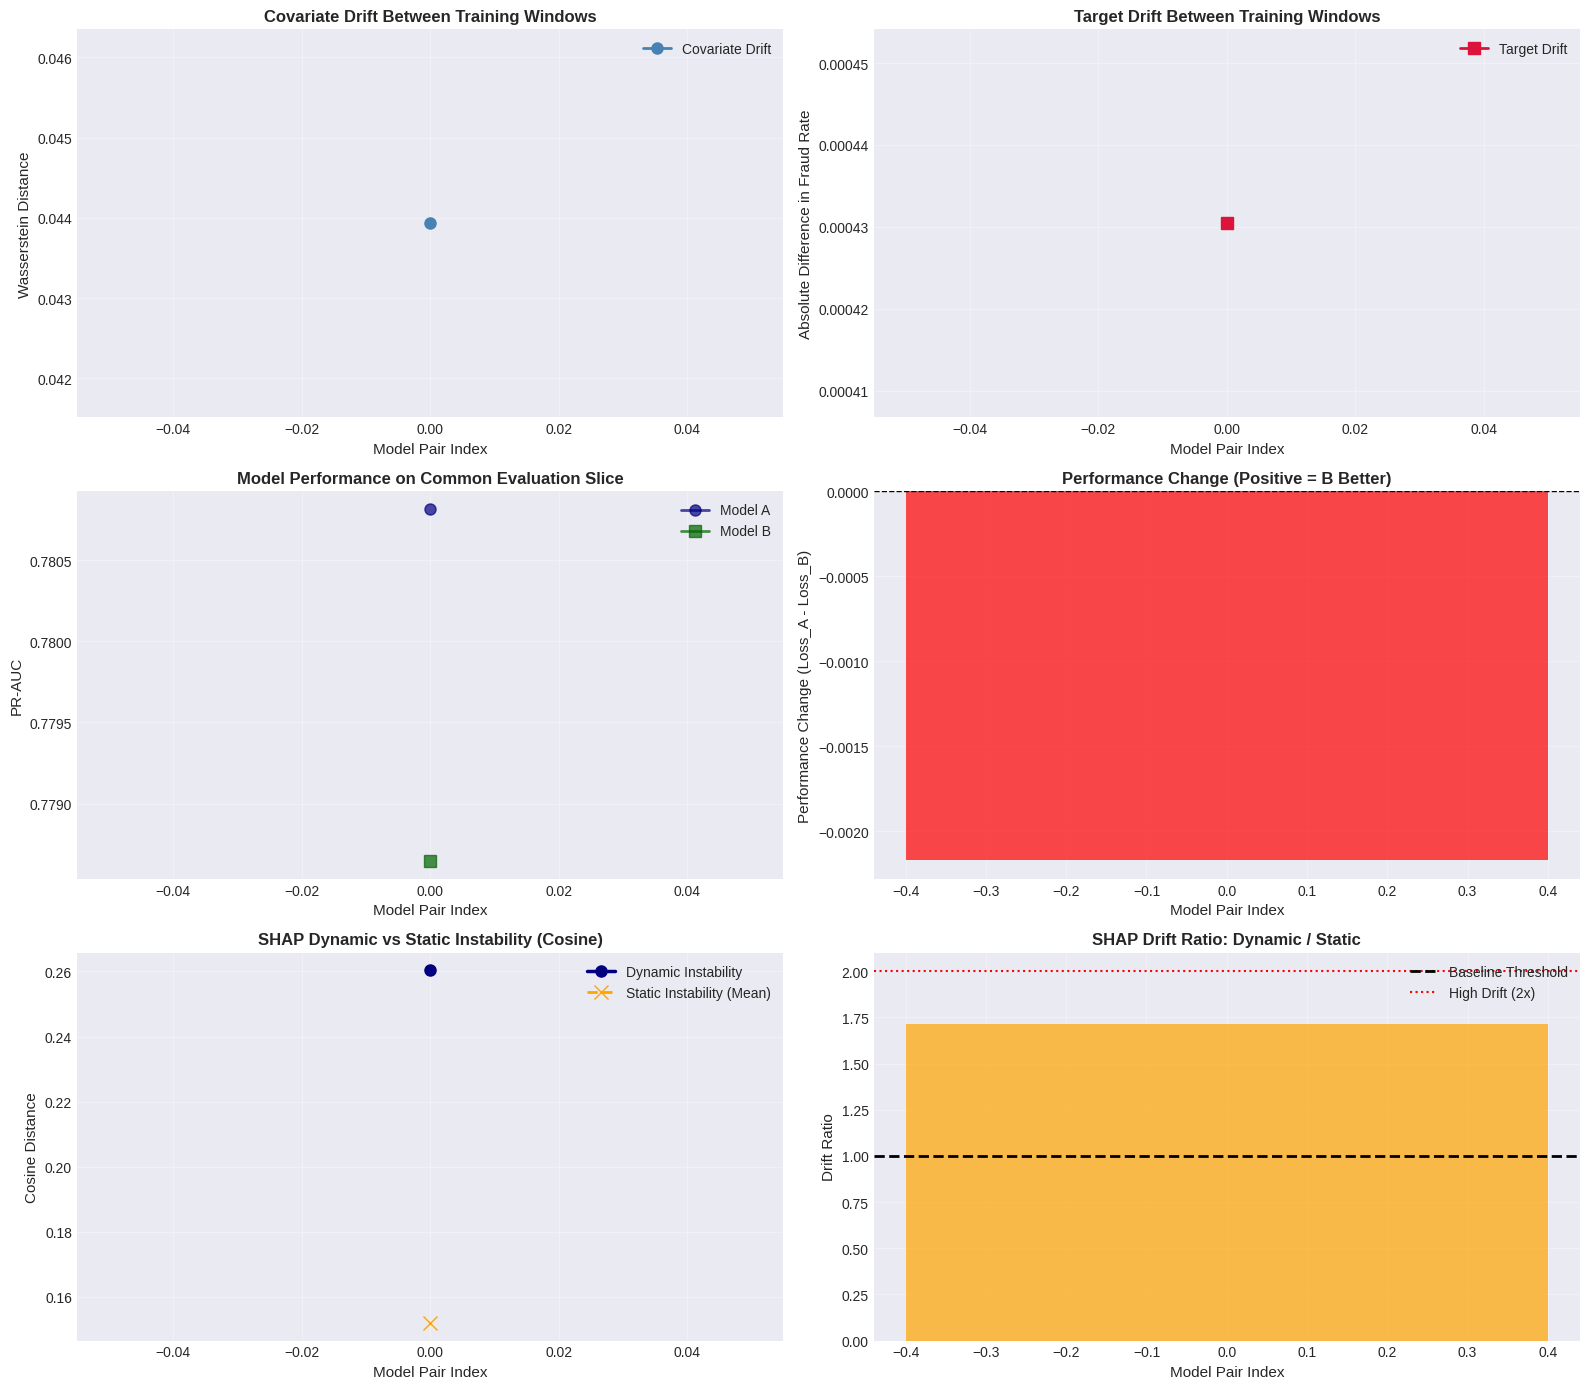

In [ ]:
# Visualizations
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Data Drift over Time
axes[0, 0].plot(results_df['pair_idx'], results_df['covariate_drift'],
                marker='o', linewidth=2, markersize=8, label='Covariate Drift', color='steelblue')
axes[0, 0].set_xlabel('Model Pair Index', fontsize=11)
axes[0, 0].set_ylabel('Wasserstein Distance', fontsize=11)
axes[0, 0].set_title('Covariate Drift Between Training Windows', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(results_df['pair_idx'], results_df['target_drift'],
                marker='s', linewidth=2, markersize=8, color='crimson', label='Target Drift')
axes[0, 1].set_xlabel('Model Pair Index', fontsize=11)
axes[0, 1].set_ylabel('Absolute Difference in Fraud Rate', fontsize=11)
axes[0, 1].set_title('Target Drift Between Training Windows', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 2. Performance Comparison
axes[1, 0].plot(results_df['pair_idx'], results_df['pr_auc_a'],
                marker='o', linewidth=2, markersize=8, label='Model A', alpha=0.7, color='navy')
axes[1, 0].plot(results_df['pair_idx'], results_df['pr_auc_b'],
                marker='s', linewidth=2, markersize=8, label='Model B', alpha=0.7, color='darkgreen')
axes[1, 0].set_xlabel('Model Pair Index', fontsize=11)
axes[1, 0].set_ylabel('PR-AUC', fontsize=11)
axes[1, 0].set_title('Model Performance on Common Evaluation Slice', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].bar(results_df['pair_idx'], results_df['delta_perf'],
               alpha=0.7, color=['green' if x > 0 else 'red' for x in results_df['delta_perf']])
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Model Pair Index', fontsize=11)
axes[1, 1].set_ylabel('Performance Change (Loss_A - Loss_B)', fontsize=11)
axes[1, 1].set_title('Performance Change (Positive = B Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# 3. SHAP Explanation Drift
if 'shap_dynamic_cos' in results_df.columns:
    axes[2, 0].plot(results_df['pair_idx'], results_df['shap_dynamic_cos'],
                    marker='o', linewidth=2.5, markersize=8, label='Dynamic Instability', color='navy')
    axes[2, 0].plot(results_df['pair_idx'], results_df['shap_static_cos_mean'],
                    marker='x', linewidth=2, markersize=10, label='Static Instability (Mean)',
                    color='orange', linestyle='--')
    axes[2, 0].set_xlabel('Model Pair Index', fontsize=11)
    axes[2, 0].set_ylabel('Cosine Distance', fontsize=11)
    axes[2, 0].set_title('SHAP Dynamic vs Static Instability (Cosine)', fontsize=12, fontweight='bold')
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].legend()

    # Add drift ratio bars with color coding
    colors = ['red' if x > 2 else 'orange' if x > 1 else 'green'
              for x in results_df['shap_drift_ratio_cos']]
    axes[2, 1].bar(results_df['pair_idx'], results_df['shap_drift_ratio_cos'],
                   alpha=0.7, color=colors)
    axes[2, 1].axhline(y=1, color='black', linestyle='--', linewidth=2, label='Baseline Threshold')
    axes[2, 1].axhline(y=2, color='red', linestyle=':', linewidth=1.5, label='High Drift (2x)')
    axes[2, 1].set_xlabel('Model Pair Index', fontsize=11)
    axes[2, 1].set_ylabel('Drift Ratio', fontsize=11)
    axes[2, 1].set_title('SHAP Drift Ratio: Dynamic / Static', fontsize=12, fontweight='bold')
    axes[2, 1].grid(True, alpha=0.3)
    axes[2, 1].legend()
else:
    axes[2, 0].text(0.5, 0.5, 'SHAP analysis not performed',
                    ha='center', va='center', transform=axes[2, 0].transAxes, fontsize=12)
    axes[2, 1].text(0.5, 0.5, 'SHAP analysis not performed',
                    ha='center', va='center', transform=axes[2, 1].transAxes, fontsize=12)

plt.tight_layout()
plt.show()

## 13. Save Results

Save the results to CSV for further analysis.

In [ ]:
# Save results to CSV
output_filename = 'temporal_stability_results.csv'
results_df.to_csv(output_filename, index=False)
print(f"✓ Results saved to: {output_filename}")

# Also save configuration for reproducibility
config_info = {
    'time_step_hours': TIME_STEP_HOURS,
    'window_length': WINDOW_LENGTH,
    'retrain_step': RETRAIN_STEP,
    'eval_horizon': EVAL_HORIZON,
    'num_replicas': NUM_REPLICAS,
    'num_features': len(feature_cols),
    'num_pairs_evaluated': len(results_df),
    'hyperparameter_tuning': 'Yes (TimeSeriesSplit CV with GridSearchCV)',
    'explanation_scope': 'Fraud-flagged transactions only',
    'fraud_threshold': 0.5
}

import json
with open('experiment_config.json', 'w') as f:
    json.dump(config_info, f, indent=2)
print(f"✓ Configuration saved to: experiment_config.json")

print("\n" + "="*80)
print("ALL RESULTS SAVED SUCCESSFULLY")
print("="*80)

✓ Results saved to: temporal_stability_results.csv
✓ Configuration saved to: experiment_config.json

ALL RESULTS SAVED SUCCESSFULLY


In [ ]:
# Load dataset
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully. Shape: {df.shape}")

# Basic check
df.head()

Dataset loaded successfully. Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
